# Experiment Results Analysis with Clean Seed Prompt

This short notebook compares three evaluator strategies (UCB, PPO, DPO) for ProTeGi-style prompt optimization on the FinQA dataset across
three compute budget levels with a clean seed prompt.

In [1]:
import json
import pathlib
import matplotlib.pyplot as plt
import numpy as np

RESULTS_DIR = pathlib.Path(".")

experiments = {
    "E20": {"evaluator": "PPO",  "budget": 1, "file": "E20_finqa_ppo.txt"},
    "E22": {"evaluator": "UCB",  "budget": 2, "file": "E22_finqa_ucb.txt"},
    "E23": {"evaluator": "PPO",  "budget": 2, "file": "E23_finqa_ppo.txt"},
    "E24": {"evaluator": "DPO",  "budget": 2, "file": "E24_finqa_dpo.txt"},
    "E25": {"evaluator": "UCB",  "budget": 3, "file": "E25_finqa_ucb.txt"},
    "E26": {"evaluator": "PPO",  "budget": 3, "file": "E26_finqa_ppo.txt"},
    "E27": {"evaluator": "DPO",  "budget": 3, "file": "E27_finqa_dpo.txt"},
}

def parse_results(filepath):
    text = filepath.read_text()
    lines = text.strip().split("\n")
    config = json.loads(lines[0])
    rounds = []
    i = 1
    while i < len(lines):
        if lines[i].startswith("======== ROUND"):
            round_num = int(lines[i].split()[-1])
            time_s = float(lines[i+1].replace("s", ""))
            est_scores = json.loads(lines[i+2])
            true_scores = json.loads(lines[i+3])
            rounds.append({
                "round": round_num,
                "time_s": time_s,
                "est_scores": est_scores,
                "true_scores": true_scores,
                "best_true": max(true_scores),
                "top_pick_true": true_scores[0],
            })
            i += 4
        else:
            i += 1
    return config, rounds

parsed = {}
for eid, meta in experiments.items():
    fp = RESULTS_DIR / meta["file"]
    if fp.exists():
        config, rounds = parse_results(fp)
        parsed[eid] = {**meta, "config": config, "rounds": rounds}

print(f"Loaded {len(parsed)} experiments.")

Loaded 7 experiments.


## Summary Table

In [2]:
print(f"{'Exp':<6} {'Evaluator':<10} {'Budget':<8} {'Baseline':>10} {'Final Best':>12} {'Gain':>8} {'Peak':>8} {'Peak Round':>12}")
print("-" * 78)

for eid, data in sorted(parsed.items()):
    baseline = data["rounds"][0]["best_true"]
    final = data["rounds"][-1]["best_true"]
    gain = final - baseline
    peak = max(r["best_true"] for r in data["rounds"])
    peak_round = max(data["rounds"], key=lambda r: r["best_true"])["round"]
    print(f"{eid:<6} {data['evaluator']:<10} {data['budget']:<8} {baseline:>10.1%} {final:>12.1%} {gain:>+8.1%} {peak:>8.1%} {peak_round:>12}")

Exp    Evaluator  Budget     Baseline   Final Best     Gain     Peak   Peak Round
------------------------------------------------------------------------------
E20    PPO        1             19.0%        23.3%    +4.2%    37.5%            1
E22    UCB        2             21.8%        48.3%   +26.6%    48.3%            6
E23    PPO        2             20.5%        32.6%   +12.1%    40.8%            3
E24    DPO        2             23.6%        46.5%   +23.0%    51.4%            4
E25    UCB        3             24.2%        58.0%   +33.8%    58.0%            6
E26    PPO        3             21.5%        52.6%   +31.1%    54.1%            5
E27    DPO        3             24.2%        44.7%   +20.5%    51.4%            1


## Accuracy Progression by Round

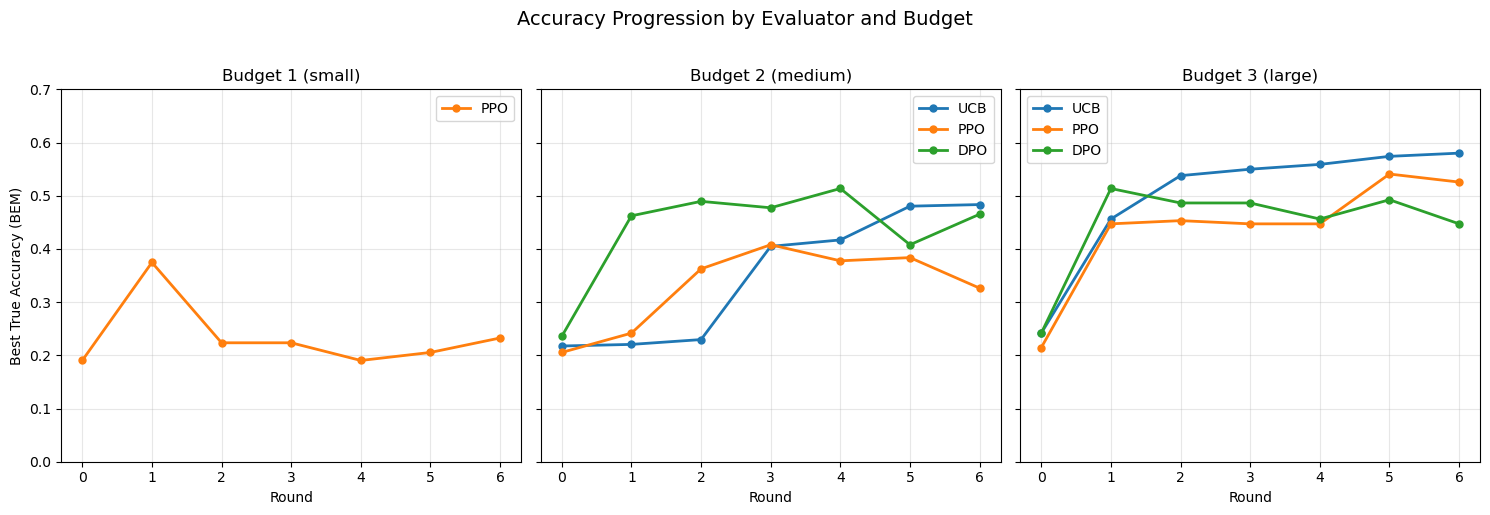

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

budget_labels = {1: "Budget 1 (small)", 2: "Budget 2 (medium)", 3: "Budget 3 (large)"}
colors = {"UCB": "#1f77b4", "PPO": "#ff7f0e", "DPO": "#2ca02c"}

for idx, budget in enumerate([1, 2, 3]):
    ax = axes[idx]
    for eid, data in sorted(parsed.items()):
        if data["budget"] != budget:
            continue
        rounds = [r["round"] for r in data["rounds"]]
        best_acc = [r["best_true"] for r in data["rounds"]]
        ax.plot(rounds, best_acc, marker="o", label=data["evaluator"],
                color=colors[data["evaluator"]], linewidth=2, markersize=5)
    ax.set_title(budget_labels[budget])
    ax.set_xlabel("Round")
    ax.set_ylim(0, 0.7)
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Best True Accuracy (BEM)")
fig.suptitle("Accuracy Progression by Evaluator and Budget", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("accuracy_progression.png", dpi=150, bbox_inches="tight")
plt.show()

## Final Accuracy Comparison

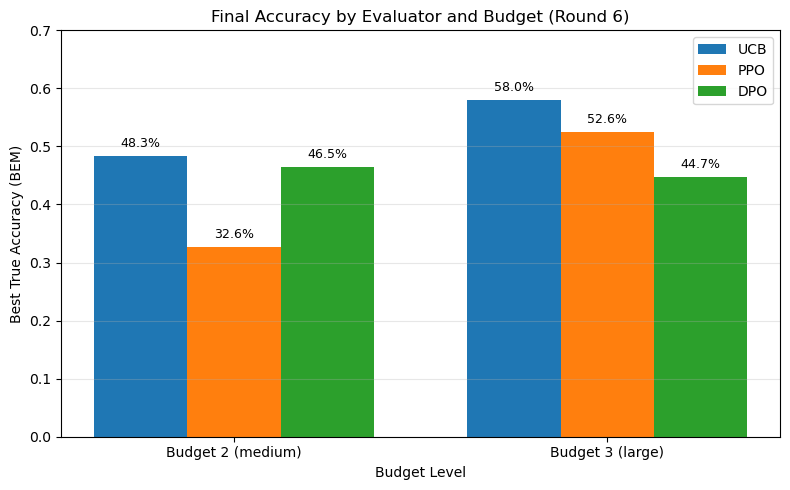

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

budgets = [2, 3]
evaluators = ["UCB", "PPO", "DPO"]
x = np.arange(len(budgets))
width = 0.25

for i, ev in enumerate(evaluators):
    vals = []
    for b in budgets:
        matches = [d for d in parsed.values() if d["evaluator"] == ev and d["budget"] == b]
        if matches:
            vals.append(matches[0]["rounds"][-1]["best_true"])
        else:
            vals.append(0)
    bars = ax.bar(x + i * width, vals, width, label=ev, color=colors[ev])
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.1%}", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Budget Level")
ax.set_ylabel("Best True Accuracy (BEM)")
ax.set_title("Final Accuracy by Evaluator and Budget (Round 6)")
ax.set_xticks(x + width)
ax.set_xticklabels(["Budget 2 (medium)", "Budget 3 (large)"])
ax.set_ylim(0, 0.7)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("final_accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Gain Over Baseline

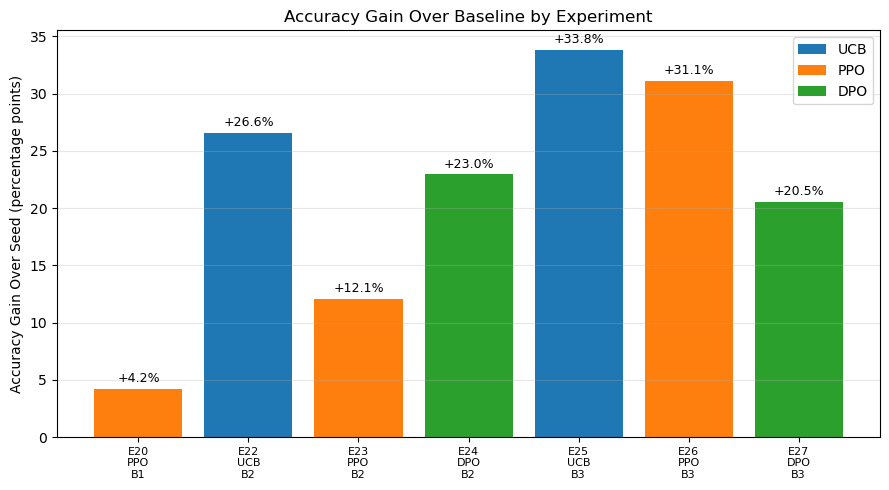

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

exp_ids = ["E20", "E22", "E23", "E24", "E25", "E26", "E27"]
gains = []
bar_colors = []
labels = []

for eid in exp_ids:
    data = parsed[eid]
    baseline = data["rounds"][0]["best_true"]
    final = data["rounds"][-1]["best_true"]
    gain = (final - baseline) * 100
    gains.append(gain)
    bar_colors.append(colors[data["evaluator"]])
    labels.append(f"{eid}\n{data['evaluator']}\nB{data['budget']}")

bars = ax.bar(range(len(exp_ids)), gains, color=bar_colors)
for bar, val in zip(bars, gains):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"+{val:.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_xticks(range(len(exp_ids)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Accuracy Gain Over Seed (percentage points)")
ax.set_title("Accuracy Gain Over Baseline by Experiment")
ax.grid(True, alpha=0.3, axis="y")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[ev], label=ev) for ev in evaluators]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig("gain_over_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

## Compute Cost (Time per Round)

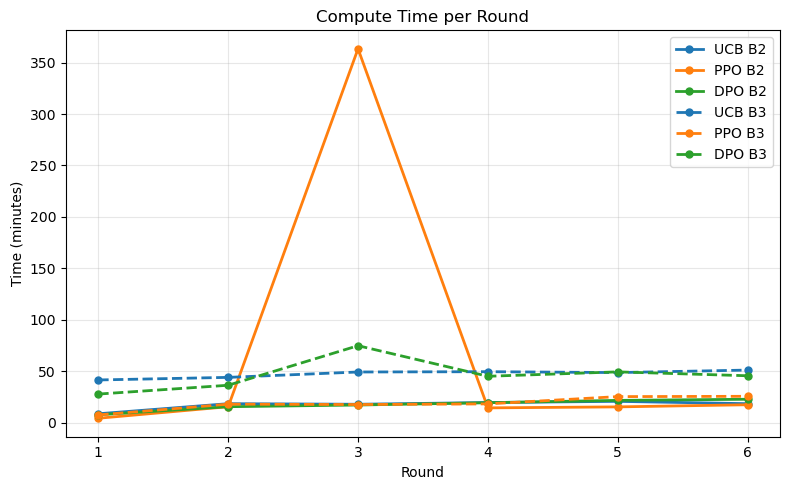

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

for eid in ["E22", "E23", "E24", "E25", "E26", "E27"]:
    data = parsed[eid]
    rounds = [r["round"] for r in data["rounds"] if r["round"] > 0]
    times = [r["time_s"] / 60 for r in data["rounds"] if r["round"] > 0]
    style = "-" if data["budget"] == 2 else "--"
    ax.plot(rounds, times, marker="o", label=f"{data['evaluator']} B{data['budget']}",
            color=colors[data["evaluator"]], linestyle=style, linewidth=2, markersize=5)

ax.set_xlabel("Round")
ax.set_ylabel("Time (minutes)")
ax.set_title("Compute Time per Round")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("time_per_round.png", dpi=150, bbox_inches="tight")
plt.show()

## Key Takeaways

1. **UCB is the strongest overall evaluator**: It reaches reaching 58.0% at budget 3 and 48.3% at budget 2.

2. **DPO is competitive at budget 2** (46.5%), nearly matching UCB and strongly beating PPO (32.6%).

3. **PPO requires larger budgets** to perform well. It is the weakest at budget 2 but reaches 52.6% at budget 3.

4. **Budget is the dominant factor.** Budget 1 barely improves over baseline (+4.3%), while budget 3 yields gains of +20-34 percentage points.

5. **Rankings by budget:**
   - Budget 2: UCB (48.3%) > DPO (46.5%) >> PPO (32.6%)
   - Budget 3: UCB (58.0%) > PPO (52.6%) > DPO (44.7%)

## Comparison with Flawed Seed Prompt

These new results require updating some of the current paper draft's content. The results below compare the two runs to show how the starting prompt affects each evaluator.

| Experiment | Evaluator | Budget | Bad Seed Final | Clean Seed Final | Difference |
|---|---|---|---|---|---|
| E20 | PPO | 1 | 12.7% | 23.3% | +10.6% |
| E22 | UCB | 2 | 21.5% | 48.3% | +26.9% |
| E23 | PPO | 2 | 27.5% | 32.6% | +5.1% |
| E24 | DPO | 2 | 23.0% | 46.5% | +23.6% |
| E25 | UCB | 3 | 57.4% | 58.0% | +0.6% |
| E26 | PPO | 3 | 39.0% | 52.6% | +13.6% |
| E27 | DPO | 3 | 29.0% | 44.7% | +15.7% |

**Observations:**

1. **DPO benefits the most from a clean seed.** At budget 2, DPO jumped from 23.0% to 46.5% (+23.6 percentage points). With the problematic seed prompt, DPO appeared to be the weakest evaluator. With a clean seed, it is nearly as strong as UCB at budget 2. DPO outperforms PPO at moderate budgets, while PPO outperforms DPO at large budgets.

2. **UCB at budget 3 was insensitive to the bad seed prompt.** It reached 57.4% with the bad seed and 58.0% with the clean seed, a negligible difference. UCB's large evaluation budget was sufficient to fully recover from the flawed starting point.

3. **PPO showed moderate sensitivity.** Its gains from the clean seed (+5.1% to +13.6%) were smaller than DPO's, suggesting it partially compensated for the bad seed on its own but not as fully as UCB.

4. **The relative ranking of evaluators changed.** With the bad seed, the ranking at
   budget 2 was PPO > DPO > UCB. With the clean seed, it is UCB > DPO >> PPO.
   This shows that conclusions about evaluator quality are sensitive to the
   starting prompt, and experiments with flawed seeds can produce misleading rankings.